## 1 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading  and Inspection of the data

In [2]:
def loading_and_inspection(file_path):
    '''
    Load the dataset and perform initial inspection.

        Parameters:
        file_path (str): The path to the CSV file containing the dataset.

        Saving the dataset

        Initial inspection includes:
        - The number of rows and columns in the dataset.
        - General information about the dataset (data types, non-null counts).
        - The total number of missing values in the dataset.
        - The columns that contain missing values.

        Returns:
        pd.DataFrame: The loaded dataset as a pandas DataFrame.

    '''
    # Loading the dataset
    df = pd.read_csv(file_path)

    # Initial inspection
    print("Initial Inspection:")
    print("*" * 50)
    print(f"The number of rows: {df.shape[0]}")
    print("*" * 50)
    print(f"\nThe number of columns: {df.shape[1]}")
    print("*" * 50)
    print(f"\nGeneral Information: {df.info()}")
    print("*" * 50)
    print(f"\nMissing Values: {df.isnull().sum().sum()}")
    print("*" * 50)
    print(f"\nColumns with missing values: {df.columns[df.isnull().any()].tolist()}")
    print("*" * 50)


    return df
    

In [3]:
df = loading_and_inspection("netflix_titles.csv")

Initial Inspection:
**************************************************
The number of rows: 8807
**************************************************

The number of columns: 12
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

General Information: None


## 3. Data Cleaning

In [4]:
# Standardize the column names incase there are leading or trailing spaces
df.columns = df.columns.str.strip()

In [5]:
print(f"Columns before cleaning: {df.columns.tolist()}")
print(f"Number of columns before cleaning: {len(df.columns)}")
# Deleting the 'show_id' column as it is not relevant for our analysis
df = df.drop(columns= "show_id")

print(f"Columns after cleaning: {df.columns.tolist()}")
print(f"Number of columns after cleaning: {len(df.columns)}")

Columns before cleaning: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Number of columns before cleaning: 12
Columns after cleaning: ['type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Number of columns after cleaning: 11


In [6]:
# Retrieving the year on date added column
df["year_added"] = pd.to_datetime(df["date_added"], errors="coerce").dt.year

df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## 4. Data Visualization and Analysis

## Basic Visualization

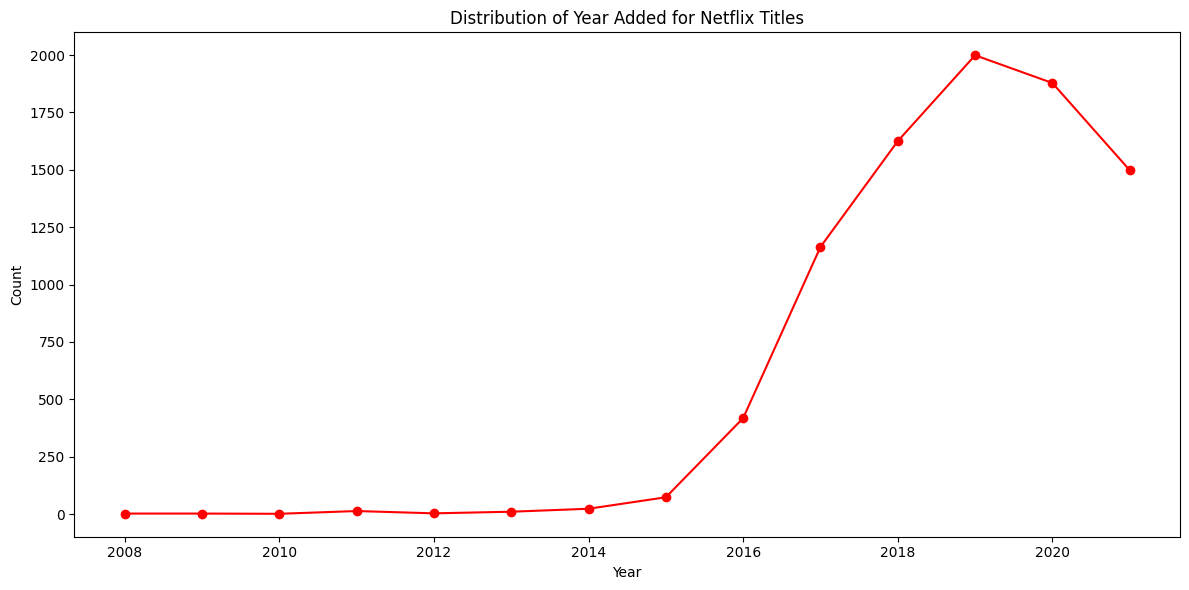

In [7]:
plt.figure(figsize=(12, 6))

width = 0.8
plt.plot(df["year_added"].value_counts().sort_index(ascending= False).dropna().index,
        df["year_added"].value_counts().sort_index(ascending= False).dropna().values,
        color= "red",
        label= "Year Added",
        marker= "o",)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Distribution of Year Added for Netflix Titles")



plt.tight_layout()
plt.show()

2019-2020, there was a significant increase in the number of shows added to Netflix, likely due to the COVID-19 pandemic and the resulting increase in demand for streaming content. The data also shows a steady increase in the number of shows added each year, with a peak in 2019. This trend may be attributed to Netflix's continued investment in original content and its expansion into international markets.

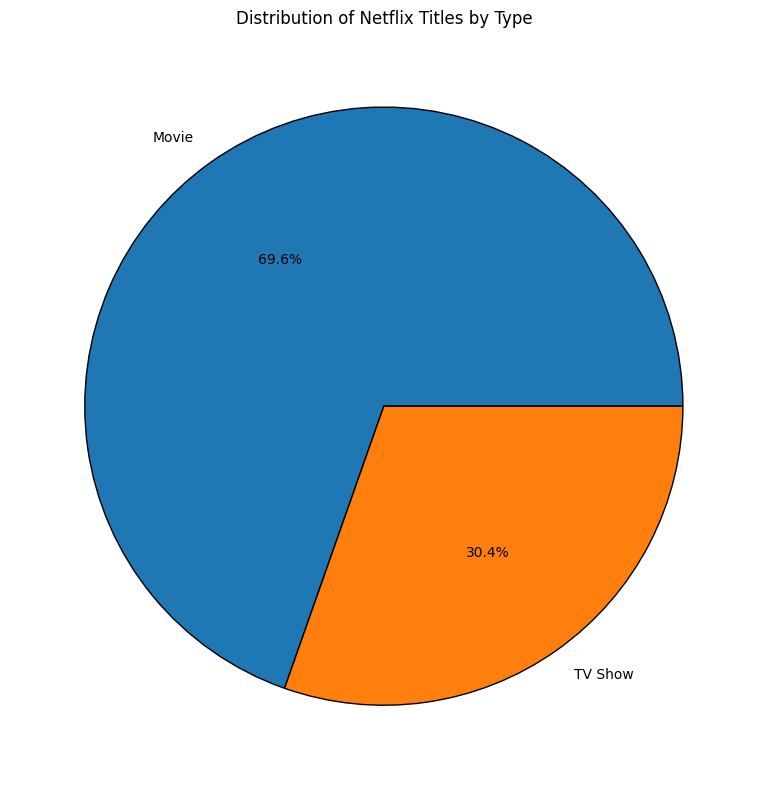

In [8]:
plt.figure(figsize=(8, 8))

plt.pie(df["type"].value_counts(), 
        labels= df["type"].value_counts().index,
        wedgeprops= {"edgecolor": "black"},
        autopct= "%1.1f%%"
        )
plt.title("Distribution of Netflix Titles by Type")

plt.tight_layout()
plt.show()

Most of the shows added to Netflix are movies, with a smaller proportion being TV shows. This is likely due to the fact that movies are generally more popular and have a wider audience than TV shows. Additionally, movies can be produced and released more quickly than TV shows, which may make them more attractive to Netflix as they look to rapidly expand their content library.

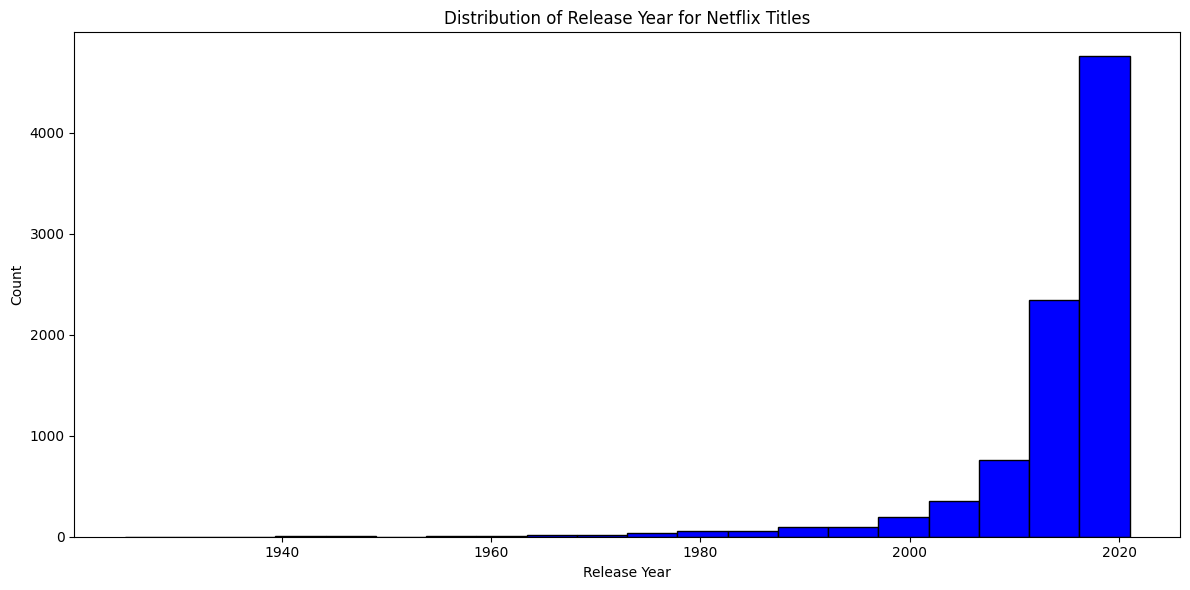

In [9]:
plt.figure(figsize=(12, 6))

plt.hist(df["release_year"], bins= 20, color= "blue", edgecolor= "black")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Distribution of Release Year for Netflix Titles")

plt.tight_layout()
plt.show()

The release years of the shows on Netflix range from 1925 to 2021, with a significant number of shows being released in the last decade. This suggests that Netflix has been actively acquiring and producing new content in recent years, which may be a response to the increasing competition in the streaming industry. The distribution of release years also indicates that there is a mix of older and newer content available on Netflix, catering to a wide range of audience preferences.

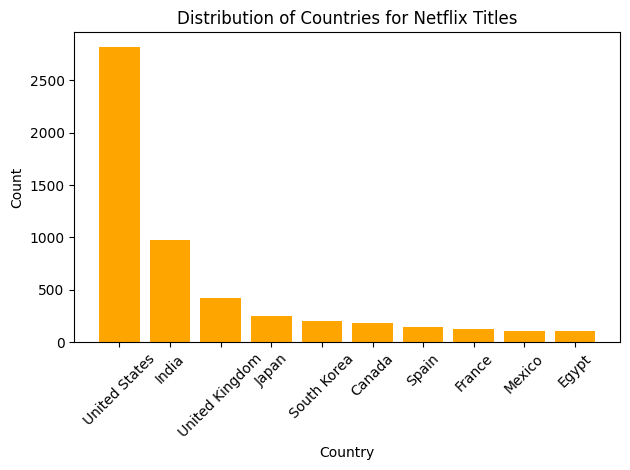

In [10]:
plt.bar(df["country"].value_counts().index[:10], 
        df["country"].value_counts()[:10], 
        color= "orange")

# Labeling the axes and title
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Distribution of Countries for Netflix Titles")
plt.xticks(rotation=45)

# Adjusting layout and displaying the plot
plt.tight_layout()
plt.show()

The top countries producing shows for Netflix are the United States, India, and the United Kingdom. This is likely due to the fact that these countries have large entertainment industries and a high demand for streaming content. Additionally, Netflix has made significant investments in producing original content in these countries, which may have contributed to the high number of shows being produced there.

## Advanced Visualizations

C:\Users\Jeremy\AppData\Local\Temp\ipykernel_19404\2067599687.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= df["type"], y= df["release_year"],palette= "Set2")


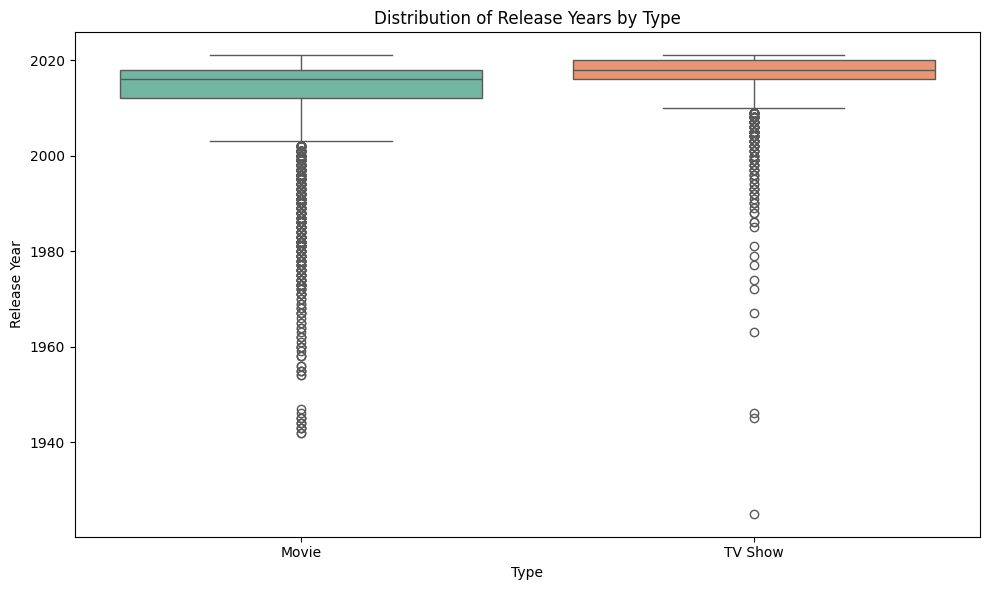

In [11]:
# Creating a box plot to visualize the distribution of release years for movies and TV shows
plt.figure(figsize=(10, 6))

sns.boxplot(x= df["type"], y= df["release_year"],palette= "Set2")

plt.xlabel("Type")
plt.ylabel("Release Year")
plt.title("Distribution of Release Years by Type")

plt.tight_layout()
plt.show()

Tv shows on Netflix tend to have been realeased from 19

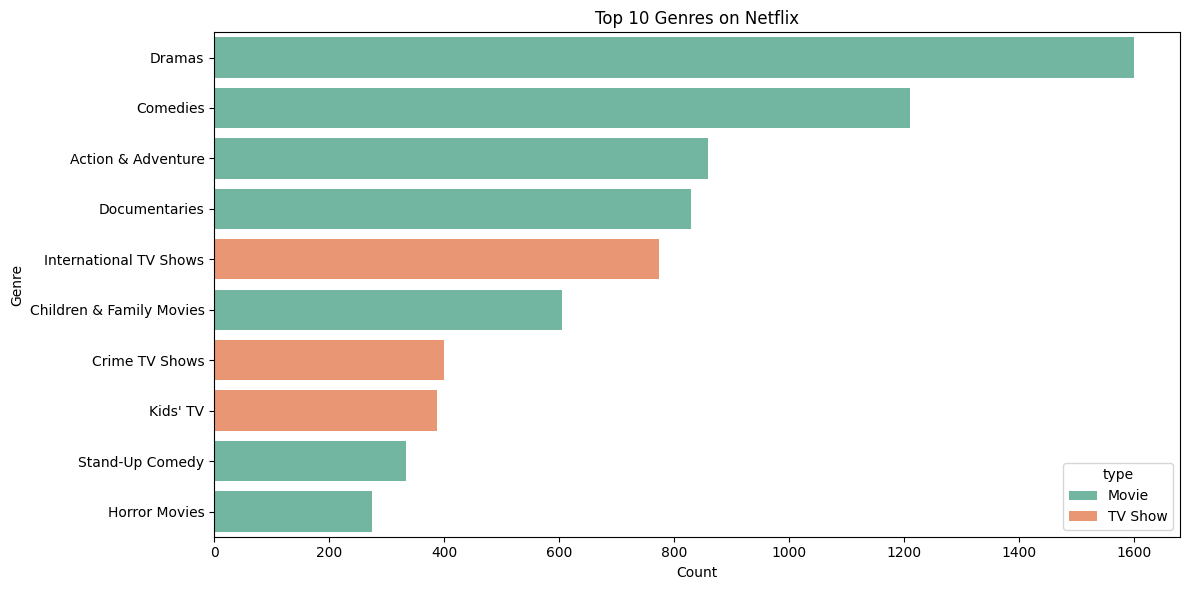

In [12]:
# Extract first genre from listed_in
df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# Get top 10 genres
top_genres = df['main_genre'].value_counts().head(10)

# Create count plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['main_genre'].isin(top_genres.index)], 
              y='main_genre', 
              order=top_genres.index,
              hue= df["type"],
              palette= "Set2")

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

Dramas movies have a high count on Netflix, which may be due to the fact that dramas are a popular genre among viewers. Dramas often explore complex characters and storylines, which can be appealing to audiences looking for engaging and emotionally resonant content. Additionally, dramas can cover a wide range of themes and topics, making them versatile and attractive to a broad audience. The high count of drama movies on Netflix may also reflect the platform's strategy to offer a diverse range of content to cater to different viewer preferences.

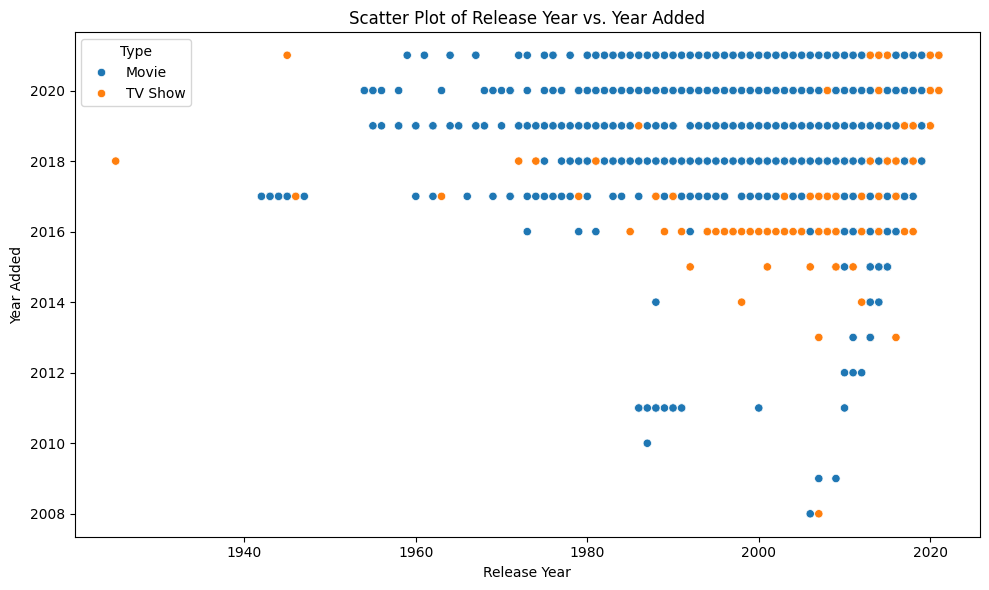

In [13]:
# Scatter plot of release year vs. year added
plt.figure(figsize=(10, 6))

sns.scatterplot(x= df["release_year"], y= df["year_added"], hue= df["type"])
plt.xlabel("Release Year")
plt.ylabel("Year Added")
plt.title("Scatter Plot of Release Year vs. Year Added")
plt.legend(title= "Type")

plt.tight_layout()
plt.show()

The movies and tv shows released in the 1900s are getting added to netflix in the 2020s. This could be due to the fact that Netflix is looking to expand its content library and attract a wider audience by offering a mix of older and newer content. Additionally, the availability of older movies and TV shows on streaming platforms has become increasingly popular in recent years, as it allows viewers to access classic content that may not be easily available through traditional channels.